# <span style="color:rgb(213,80,0)">複合反応系の物質収支と熱収支</span>

前回までに等温のCSTRの解析および最適化について説明しました。化学反応では、反応熱が発生しますので、熱収支も考慮すべきです。

　本日はCSTRを対象として、

- 物質収支の復習および熱収支式の理論式
- MATLABによる解析コード

を学習してもらいます。

#### CSTRにおける物質収支一般式

成分 $i$ の物質収支の基本系は次式で表されます。

&#160;&#160;&#160;&#160;
$$\frac{dC_i }{dt}=\frac{C_{i,\mathrm{in}} -C_i }{\tau }+\sum_{j=1}^{N_r } \nu_{ij} r_j$$

- $\nu_{ij}$:成分 $i$ に対する反応 $j$ の化学量論係数（生成＝正、消費＝負）
- $r_j$ ；は反応速度

右辺第１項は、反応液の流入 $C_{i,\mathrm{in}}$ と流出 $C_i$ です、記号 $i$ は成分を表す変数ですので、流入の $in$ と混同しないように注意してください。

具体例

$$\begin{array}{l} A\;\overset{k_1 }{\to} \;D\;\overset{k_2 }{\to} \;U\newline A+A\;\overset{k_3 }{\to} \;P \end{array}$$

 の場合

$$\begin{array}{l} j=1:A\;\overset{k_1 }{\to} \;D\newline j=2:D\;\overset{k_2 }{\to} \;U\newline j=3:2A\;\overset{k_3 }{\to} \;P \end{array}$$

となり、成分Aの物質収支( $i=\mathbf{A}$ )の場合は

$$\frac{dC_A }{dt}=\frac{C_{A,\mathrm{in}} -C_A }{\tau }+(-1\cdot r_1 -2\cdot r_3 )$$

となります。成分B,Cについても同じ要領ですが、後ほどにも出てきますので、ここでは省略します。

#### CSTRにおけるエンタルピー収支の一般式

エンタルピー収支式も、物質収支同様に

(蓄積）＝(流入)ー(流出)＋(系内での生成）+(伝熱など）

から立式します。エネルギーの変化速度ですので、各項の単位はJ/s (W)となります。

- **蓄積**： $\frac{d}{dt}\left(\rho c_p VT\right)$ で、特に $\rho ,c_p ,V$ が時間不変であれば $\rho c_p V\frac{dT}{dt}$.
- **流入\-流出項**:　温度 $T_{in}$ の流体が反応器に流入することによるエンタルピー増加 $\rho c_p FT_{in}$ と温度 $T$ の反応器流体の流出によるエンタルピー減少 $\rho c_p FT$ の差
- **系内での生成**:反応エンタルピーが相当します。各反応 $j$ の速度 $r_j$: \[mol/(m³·s)\] と反応エンタルピー $\Delta H_j$ : \[J/mol\]の総和で $V\sum_{j=1}^{N_r } (-\Delta H_j )r_j$ 　（ $\Delta H_j$:正のとき吸熱反応、負のとき発熱反応）
- **伝熱：**ジャケットなどの反応器の保温、冷却機構によるエンタルピー増減。ジャケット内冷媒温度 $T_c$ と反応液温度 $T$ に総括伝熱係数 $U$ \[J/(m $^2$ s K)\] と伝熱面積 $A$  を使って, $UA(T_c -T)$ で表せる。

　以上をあわせて、両辺を $\rho c_p V$ で除すると温度に関する式を得る。

&#160;&#160;&#160;&#160;
$$\frac{dT}{dt}=\frac{(T_{\mathrm{in}} -T)}{\tau }+\frac{1}{\rho c_p }\sum_{j=1}^{N_r } (-\Delta H_j )r_j +\frac{UA}{\rho c_p V}(T_c -T)$$

- $\rho$ ：密度
- $C_p$ ：比熱
- $\Delta H_j$ ：反応 j の反応エンタルピー
- $UA$ ：総括伝熱係数 $U\times A$ 伝熱面積 （J/s/K）
- $T_c$ ：外部熱媒体温度（ジャケット温度）
- $\tau$:滞留時間(=V/F)

反応系

$$\begin{array}{l} A\;\overset{k_1 }{\to} \;D\;\overset{k_2 }{\to} \;U\newline A+A\;\overset{k_3 }{\to} \;P \end{array}$$

に適用すると

$$\frac{dT}{dt}=\frac{T_{in} -T}{\tau }-\frac{1}{\rho c_p }\left(\Delta H_1 r_1 +\Delta H_2 r_2 +\Delta H_3 r_3 \right)+\frac{UA}{\rho c_p V}(T_c -T)$$

非等温複合反応CSTRモデル式まとめ

**反応系**

$$\begin{array}{l} A\;\overset{k_1 }{\to} \;D\;\overset{k_2 }{\to} \;U\newline A+A\;\overset{k_3 }{\to} \;P \end{array}$$

**物質収支**


$$\begin{array}{l} \frac{dC_A }{dt}=\frac{C_{A,in} -C_A }{\tau }-r_1 -2r_3 　\newline \frac{dC_D }{dt}=\frac{C_{D,in} -C_D }{\tau }+r_1 -r_2 \newline \frac{dC_U }{dt}=\frac{C_{U,in} -C_U }{\tau }+r_2 \newline \frac{dC_P }{dt}=\frac{C_{P,in} -C_P }{\tau }+r_3  \end{array}$$

**反応速度**

$$r_1 =k_1 C_A ,~~r_2 =k_2 C_D ,~~r_3 =k_3 C_A^2$$


$$\begin{array}{l} k_1 =k_{10} \exp \left(-\frac{E_1 }{RT}\right)\newline k_2 =k_{20} \exp \left(-\frac{E_2 }{RT}\right)\newline k_3 =k_{30} \exp \left(-\frac{E_3 }{RT}\right) \end{array}$$

**エンタルピー収支**

$$\frac{dT}{dt}=\frac{T_{in} -T}{\tau }-\frac{1}{\rho c_p }\left(\Delta H_1 r_1 +\Delta H_2 r_2 +\Delta H_3 r_3 \right)$$

- $C_A ,C_D ,C_U ,C_P$ : 各成分の濃度 \[mol/m\textasciicircum{}3\]
- $T$ : 温度 \[K\]
- $k_1 ,k_2 ,k_3$ : 反応速度定数
- $\Delta H_1 ,\Delta H_2 ,\Delta H_3$ : 反応熱 \[J/mol\]
- $\tau$ : 滞留時間 \[s\]
- $\rho$ : 密度 \[kg/m^3\]
- $c_p$ : 比熱 \[J/kg/K\]
- $C_{i,in}$   : 流入濃度 \[mol/m^3\]
- $T_{in}$ : 流入温度 \[K\]

解析コードを以下に示します。極めて単純なコードであるため、解読もしてください。出力されるグラフが小さくてみにくい場合は、拡大したいグラフをクリックしてください。左上部に”Figureウィンドウで開く”が表示されますので、そこをクリックすれば、見やすいグラフが表示されます。

- パラメーター、定数の定義
- 初期条件、反応時間の設定
- ode15sで連立微分方程式の数値計算
- 結果の表示
- 関数定義



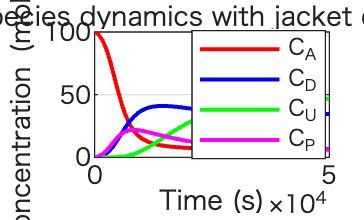

In [1]:
%% CSTR 複合反応のダイナミクス解析（ジャケット冷却付き）
clear; clc; close all;


%% パラメータ（与えられた値／必要に応じて調整）
%k,Eは[1X3]のベクトルで与えました。
%function odefunでこの値を読む時は、k(1),k(2),k(3)と記述します。
k = [1.777e8, 5.326e6, 6.223e4];  % k1, k2, k3 [1/s, 1/s, m^3/(mol·s)]
E = [7.878e4, 7.479e4, 6.842e4];  % E1, E2, E3 [J/mol]
R = 8.3145;                        % J/mol/K


% 反応熱 [J/mol]（負が発熱）
% マイナス記号があるのは発熱、吸熱の場合は、正の値に修正）
 H = [-4.2e4, -11e4, -41.85e4];
% CSTR条件
V   = 1e2;      % 反応器容積m^3
F   = 1e-2;     % 反応液供給速度m^3/s
C_A0 = 100.0;     % mol/m^3（inlet A）
T0   = 300;     % 初期温度 [K]
Tin  = 380;     % 入口温度 [K]


rho = 1000;     % kg/m^3
Cp  = 4.18e3;   % J/kg/K


% ジャケット冷却（新規）
%ジャケットなしの場合はUA = 0とすれば良い;  % W/K  ← 例: UA/(rho*Cp*V) ≈ 3e6/(1000*4180*100) ≈ 7.18e-3 [1/s]
UA = 3.0e4;     % W/K  ← 例: UA/(rho*Cp*V) ≈ 3e6/(1000*4180*100) ≈ 7.18e-3 [1/s]
Tc = 350;       % K（ジャケット媒体の温度）
%%%%%%%%%%%%%%%%%%
%% 初期条件
C0 = [C_A0; 0; 0; 0];  % [A, D, U, P]
y0 = [C0; T0];         % [C_A, C_D, C_U, C_P, T]


%% 時間範囲
tspan = [0 50000];  % s


%% ODE解法
[t, y] = ode15s(@(t,y) odefun(t, y, k, E, R, H, F, V, rho, Tin, Cp, C_A0, UA, Tc), tspan, y0);


%% プロット（濃度）
figure('Color','w');
plot(t, y(:,1), 'r', 'LineWidth', 1.5); hold on;
plot(t, y(:,2), 'b', 'LineWidth', 1.5);
plot(t, y(:,3), 'g', 'LineWidth', 1.5);
plot(t, y(:,4), 'm', 'LineWidth', 1.5);
xlabel('Time (s)'); ylabel('Concentration (mol/m^3)');
legend('C_A','C_D','C_U','C_P', 'Location','best');
title('Species dynamics with jacket cooling');
grid on;


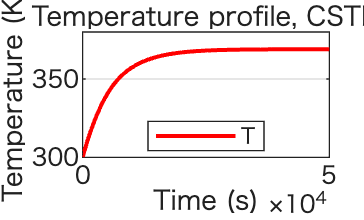

In [2]:


%% プロット（温度）
figure('Color','w');
plot(t, y(:,5), 'r', 'LineWidth', 1.5);
xlabel('Time (s)'); ylabel('Temperature (K)');
legend('T', 'Location','best');
title('Temperature profile, CSTR');
grid on;

 Iter  Func-count            Fval   Feasibility   Step Length       Norm of   First-order  
                                                                       step    optimality
    0           6    3.327372e+01     0.000e+00     1.000e+00     0.000e+00     6.153e+02  
    1          17    3.267202e+01     0.000e+00     1.681e-01     3.401e-02     3.302e+02  
    2          23    3.165089e+01     0.000e+00     1.000e+00     3.551e+00     8.007e+01  
    3          29    3.000359e+01     0.000e+00     1.000e+00     1.158e+01     1.859e+02  
    4          35    2.903750e+01     0.000e+00     1.000e+00     8.396e+00     2.312e+02  
    5          41    2.844789e+01     0.000e+00     1.000e+00     9.067e-01     1.730e+02  
    6          47    2.653876e+01     0.000e+00     1.000e+00     4.930e+00     4.198e+01  
    7          53    2.360047e+01     0.000e+00     1.000e+00     1.086e+01     1.225e+01  
    8          59    7.624624e+00     0.000e+00     1.000e+00     5.379e+01     2.


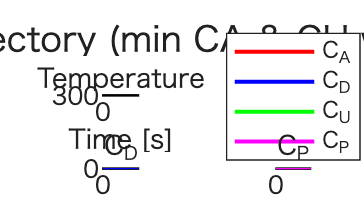

In [3]:


%%%%%%add


%% ========= 最適化ユーティリティ =========
% 目的：CD>CP を満たしつつ CA と CU を極小化
% 変数：x=[F, Tin, UA, Tc, CA0]
% 既存の odefun を呼び出して定常近傍値を評価します


function result = optimize_CSTR_minCA_CU_CDgtCP(k,E,R,H,V,rho,Cp, y0_base, T0_base)
    % ----- ユーザ調整パラメータ -----
    delta = 0.2;     % CD>CP のマージン（mol/m^3）
    Tmax  = 500.0;   % 上限温度（K）
    wA    = 1.0;     % 目的関数の CA 重み
    wU    = 1.0;     % 目的関数の CU 重み
    alpha = 50.0;    % CD>CP 未達ペナルティ係数（Toolbox無のとき）
    beta  = 10.0;    % 温度上限超過ペナルティ係数


    % 変数の下限・上限（物理的に妥当な範囲）
    lb = [ 1e-3,  320,    0,   280,   1 ];     % [F, Tin, UA, Tc, CA0]
    ub = [ 2e-1,  400, 1e6,   360,  100 ];


    % 初期推定（現在値近傍）
    x0 = [ 1.0e-2, 350, 3.0e4, 350, 100.0 ];


    % 初期状態テンプレート（温度のみベース）
    y0 = y0_base; y0(5) = T0_base;


    hasOptTool = license('test','Optimization_Toolbox');


    if hasOptTool
        % ====== fmincon（SQP）で厳密制約付き最適化 ======
        options = optimoptions('fmincon','Algorithm','sqp','Display','iter',...
                               'MaxFunctionEvaluations',3e3,'MaxIterations',300);


        [x_opt, J_opt] = fmincon( ...
            @(x) obj_minCA_CU(x,k,E,R,H,V,rho,Cp,y0,wA,wU), ...
            x0, [], [], [], [], lb, ub, ...
            @(x) nonlcon_CDgtCP(x,k,E,R,H,V,rho,Cp,y0,delta,Tmax), options);


        [~, ss] = obj_minCA_CU(x_opt,k,E,R,H,V,rho,Cp,y0,wA,wU);
        result.method = 'fmincon';
        result.x_opt  = x_opt;
        result.J_opt  = J_opt;
        result.ss     = ss;     % [CA,CD,CU,CP,T]
    else
        % ====== ペナルティ付き粗探索（グリッド＋ランダム） ======
        F_list   = [2e-2, 5e-2, 1e-1, 2e-1];
        Tin_list = [330, 340, 350];
        UA_list  = [2e5, 5e5, 8e5];
        Tc_list  = [300, 320, 340];
        CA0_list = [6, 8, 10, 20, 40];


        best.J  = Inf; best.x = []; best.ss = [];
        % グリッド探索
        for F = F_list
            for Tin = Tin_list
                for UA = UA_list
                    for Tc = Tc_list
                        for CA0 = CA0_list
                            x = [F,Tin,UA,Tc,CA0];
                            [J, ss] = obj_penalty_minCA_CU_CDgtCP(x,k,E,R,H,V,rho,Cp,y0,...
                                               wA,wU,delta,Tmax,alpha,beta);
                            if J < best.J
                                best.J = J; best.x = x; best.ss = ss;
                            end
                        end
                    end
                end
            end
        end
        % ランダムシェイク（追加 200 サンプル）
        rng(0);
        for r = 1:200
            xr = lb + rand(1,5).*(ub - lb);
            [J, ss] = obj_penalty_minCA_CU_CDgtCP(xr,k,E,R,H,V,rho,Cp,y0,...
                                   wA,wU,delta,Tmax,alpha,beta);
            if J < best.J
                best.J = J; best.x = xr; best.ss = ss;
            end
        end


        result.method = 'penalty-grid+random';
        result.x_opt  = best.x;
        result.J_opt  = best.J;
        result.ss     = best.ss;
    end


    % 結果表示
    fprintf('\n=== Optimization result (%s) ===\n', result.method);
    fprintf('F=%.3e m^3/s, Tin=%.1f K, UA=%.2e W/K, Tc=%.1f K, CA0=%.1f mol/m^3\n', ...
        result.x_opt(1), result.x_opt(2), result.x_opt(3), result.x_opt(4), result.x_opt(5));
    fprintf('Steady approx: CA=%.3f, CD=%.3f, CU=%.3f, CP=%.3f, T=%.1f K\n', ...
        result.ss(1), result.ss(2), result.ss(3), result.ss(4), result.ss(5));
    fprintf('Objective J=%.3f  (wA*CA + wU*CU + penalties)\n', result.J_opt);


    % ベスト条件の時系列可視化
    plot_best_trajectory(result.x_opt,k,E,R,H,V,rho,Cp,y0);
end
%%%%%%%


% 最適化の実行（y0, T0 は既存を使用）
result = optimize_CSTR_minCA_CU_CDgtCP(k,E,R,H,V,rho,Cp, y0, T0);


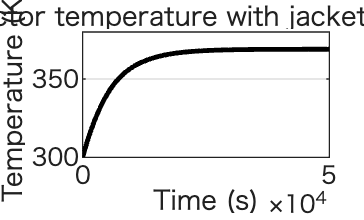

In [4]:
% ベスト解は result.x_opt（[F, Tin, UA, Tc, CA0]）
% 定常近傍の値は result.ss（[CA, CD, CU, CP, T]）


%%%%%%%


% ----- 目的関数（Toolboxあり：ペナルティなし、厳密制約は nonlcon で） -----
function [J, ss] = obj_minCA_CU(x,k,E,R,H,V,rho,Cp,y0,wA,wU)
    [ss, ~] = eval_ss(x,k,E,R,H,V,rho,Cp,y0);
    CA=ss(1); CD=ss(2); CU=ss(3); CP=ss(4); T=ss(5);
    J = wA*CA + wU*CU;   % 主目的：CA と CU を最小化
end


% ----- 非線形制約：CD>=CP+δ と 温度上限 -----
function [c, ceq] = nonlcon_CDgtCP(x,k,E,R,H,V,rho,Cp,y0,delta,Tmax)
    [ss, ~] = eval_ss(x,k,E,R,H,V,rho,Cp,y0);
    CA=ss(1); CD=ss(2); CU=ss(3); CP=ss(4); T=ss(5);
    c1 = CP - CD + delta;     % c1<=0：CD >= CP+δ
    c2 = T - Tmax;            % c2<=0：温度上限
    c   = [c1; c2];
    ceq = [];
end


% ----- 目的関数（Toolboxなし：CD>CP と温度にペナルティ） -----
function [J, ss] = obj_penalty_minCA_CU_CDgtCP(x,k,E,R,H,V,rho,Cp,y0,wA,wU,delta,Tmax,alpha,beta)
    [ss, ~] = eval_ss(x,k,E,R,H,V,rho,Cp,y0);
    CA=ss(1); CD=ss(2); CU=ss(3); CP=ss(4); T=ss(5);
    J = wA*CA + wU*CU;
    J = J + alpha*max(0, CP - CD + delta)^2;
    J = J + beta *max(0, T - Tmax)^2;
end


% ----- 定常近傍の評価（動的に t_end を選ぶ） -----
function [ss, traj] = eval_ss(x,k,E,R,H,V,rho,Cp,y0)
    F=x(1); Tin=x(2); UA=x(3); Tc=x(4); CA0=x(5);
    tau   = V / F;
    t_end = min(6.0e4, max(5.0e3, 5.0*tau));  % 目安：5τ 〜 6e4 s
    tspan = [0, t_end];


    % 初期条件（供給濃度を反映）
    y0_use = y0;
    y0_use(1) = CA0;
    y0_use(2:4) = 0;


    % 既存の odefun をそのまま利用
    odef = @(t,y) odefun(t,y,k,E,R,H,F,V,rho,Tin,Cp,CA0,UA,Tc);
    opts = odeset('RelTol',1e-8,'AbsTol',1e-10);
    [t,y] = ode15s(odef, tspan, y0_use, opts);


    % 定常近傍値：末尾の値（必要なら終端10%の平均に変更可）
    ss = [y(end,1), y(end,2), y(end,3), y(end,4), y(end,5)];
    traj.t = t; traj.y = y;
end


% ----- ベスト条件の時系列プロット -----
function plot_best_trajectory(x_best,k,E,R,H,V,rho,Cp,y0)
    [ss, traj] = eval_ss(x_best,k,E,R,H,V,rho,Cp,y0);
    t = traj.t; y = traj.y;
    figure('Color','w'); tiledlayout(2,2);
    nexttile;
    plot(t,y(:,5),'k','LineWidth',1.8); grid on;
    xlabel('Time [s]'); ylabel('T [K]'); title('Temperature');


    nexttile;
    plot(t,y(:,1),'r','LineWidth',1.5); hold on;
    plot(t,y(:,2),'b','LineWidth',1.5);
    plot(t,y(:,3),'g','LineWidth',1.5);
    plot(t,y(:,4),'m','LineWidth',1.5);
    legend('C_A','C_D','C_U','C_P','Location','best'); grid on;
    xlabel('Time [s]'); ylabel('Conc [mol/m^3]'); title('Species');


    nexttile; plot(t,y(:,2),'b','LineWidth',1.8); grid on; title('C_D');
    nexttile; plot(t,y(:,4),'m','LineWidth',1.8); grid on; title('C_P');
    sgtitle('Best trajectory (min CA & CU with CD>CP)');
end


%%%
%% プロット（温度）
figure('Color','w');
plot(t, y(:,5), 'k', 'LineWidth', 1.8);
xlabel('Time (s)'); ylabel('Temperature (K)');
title('Reactor temperature with jacket cooling');
grid on;

In [5]:


%% ODE関数（ジャケット冷却項を含む熱収支）
function dydt = odefun(~, y, k, E, R, H, F, V, rho, Tin, Cp, C_A0, UA, Tc)
    % 変数
    C_A = y(1);
    C_D = y(2);
    C_U = y(3);
    C_P = y(4);
    T   = y(5);

    % 反応速度（Arrhenius式）
    % r1 = k1*C_A, r2 = k2*C_D, r3 = k3*C_A^2
    r1 = k(1)*exp(-E(1)/(R*T))*C_A;
    r2 = k(2)*exp(-E(2)/(R*T))*C_D;
    r3 = k(3)*exp(-E(3)/(R*T))*C_A^2;

    % 物質収支（CSTR）
    dCAdt = F/V*(C_A0 - C_A) - r1 - 2*r3;
    dCDdt = -F/V*C_D + r1 - r2;
    dCUdt = -F/V*C_U + r2;
    dCPdt = -F/V*C_P + r3;

    % 熱収支（混合 + 反応熱 + ジャケット冷却）
    % dT/dt = (Tin - T)/tau - (1/(rho*Cp))*(H1*r1 + H2*r2 + H3*r3) + (UA/(rho*Cp*V))*(Tc - T)
    % ここで tau = V/F、よって (Tin - T)/tau = (F/V)*(Tin - T)
    Qrxn = H(1)*r1 + H(2)*r2 + H(3)*r3;              % J/(m^3*s)
    dT_mix = (F/V)*(Tin - T);                        % 混合冷却項
    dT_jkt = (UA/(rho*Cp*V))*(Tc - T);               % ジャケット冷却項
    dTdt   = dT_mix - (1/(rho*Cp))*Qrxn + dT_jkt;

    % 出力
    dydt = [dCAdt; dCDdt; dCUdt; dCPdt; dTdt];
end


コードを実行しましたか？表示されたグラフをください。

このCSTRの解析ではスタートアップから計算を実行しておりますので、各成分濃度および温度は時間とともに変化し、やがて定常に達します。

 **定常になったでしょうか？** この後、パラメーターを変更してもらいますが、定常になっていない場合、反応時間を拡大してみてください。場所は

<pre>
%% 時間範囲
tspan = [0 50000];  % s
</pre>

の行で、50000を適切な値に変更してください。